# Antibunching of 4 fluorophores in different conditions

In [ ]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

for package in [dist, fi, fl, tr, rt]:
    print(f"{package.__name__} version: {package.__version__}")

reading_from = r"D:\python_output\Chapter_I\1_12_multi_f_antibunching"

fluopy.distributions version: 0.1.0
fluopy.figure version: 0.1.0
fluopy.fluorophores version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.routines version: 0.1.0


## Reading the data

In [ ]:
reading_from_OET = reading_from + r"\OET"
reading_from_noOET = reading_from + r"\noOET"
reading_from_OEThighSSA = reading_from + r"\OEThighSSA"
reading_from_OETnoSSA = reading_from + r"\OETnoSSA"
reading_from_noDSTORM = reading_from + r"\noDSTORM"
reading_from_noDSTORMrisc = reading_from + r"\noDSTORMrisc"

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 6)
fig = plt.figure(figsize=(12, 10.5))

rng = np.random.default_rng(42)

identifiers = ["3nm", "6nm", "9nm", "18nm"]
for i, r_from in enumerate(
    [
        reading_from_OET,
        reading_from_noOET,
        reading_from_OEThighSSA,
        reading_from_OETnoSSA,
        reading_from_noDSTORM,
        reading_from_noDSTORMrisc,
    ]
):
    for j, id in enumerate(identifiers):
        for file in glob.glob(r_from + "/*"):
            if file == r_from + r"\event_time_points_" + f"{id}" + ".npy":
                event_time_points = np.load(file)
                hist, bins = fcs_p.coincidence(
                    event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng
                )
                ax = fig.add_subplot(gs[j, i])
                fi.universal_figure(
                    axes=ax,
                    type_="line",
                    data=[bins[:-2], hist / np.max(hist)],
                    ylim=[0, 1],
                    ylabel=r"$g^{(2)}(\tau)$",
                    xlabel="Delay (s)",
                    color=colors[j],
                    tick_style_x="sci",
                )

col_titles = ["OET", "no OET", "OET high SSA", "OET no SSA", "no DSTORM"]
for i, title in enumerate(col_titles):
    fig.text(
        0.16 + i * 0.16,
        0.94,
        title,
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
    )


for i, title in enumerate(identifiers):
    fig.text(
        0.04,
        0.82 - i * 0.22,
        title,
        ha="right",
        va="center",
        fontsize=12,
        weight="bold",
        rotation="vertical",
    )

fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

KeyboardInterrupt: 

<Figure size 1200x1050 with 0 Axes>

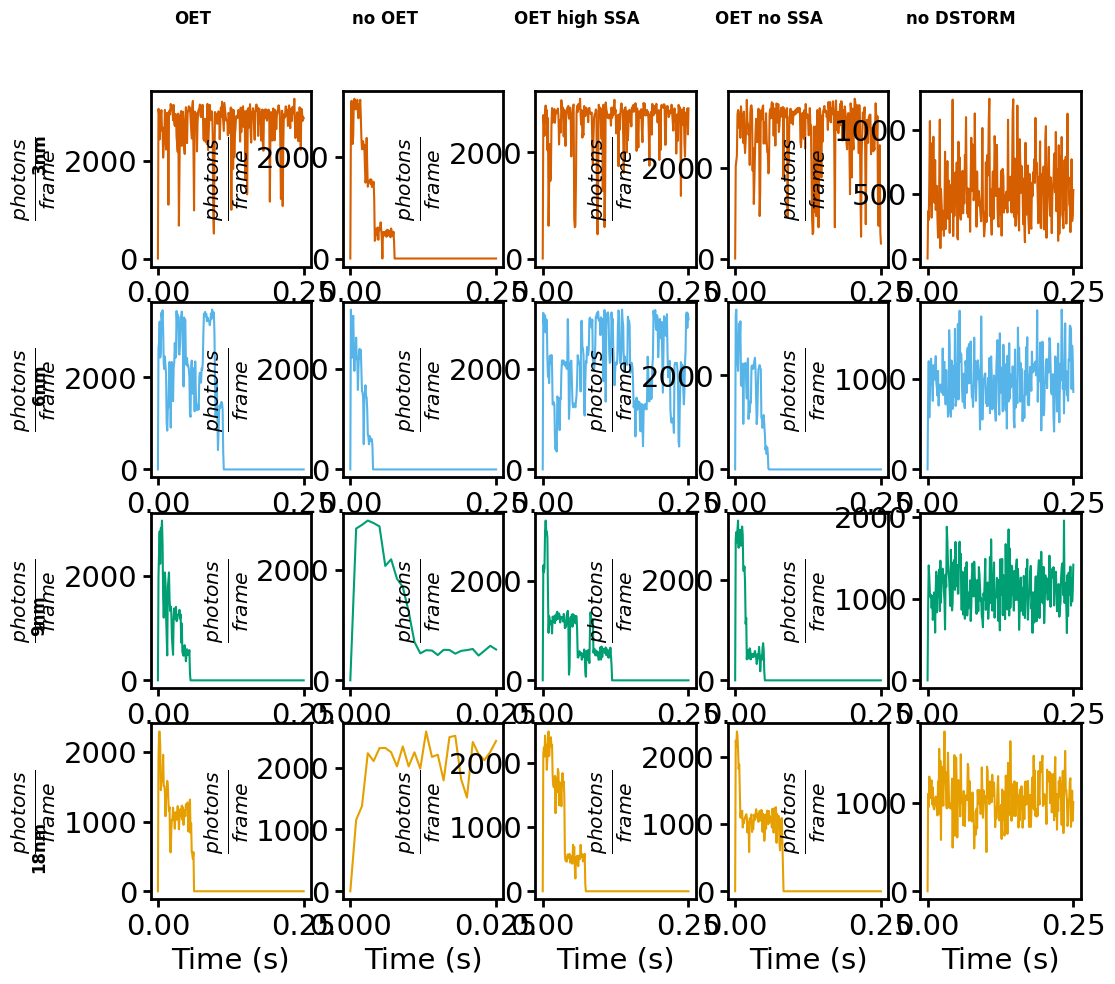

In [ ]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 5)
fig = plt.figure(figsize=(12, 10.5))

rng = np.random.default_rng(42)

emis = em.Emissions()
identifiers = ["3nm", "6nm", "9nm", "18nm"]
for i, r_from in enumerate(
    [
        reading_from_OET,
        reading_from_noOET,
        reading_from_OEThighSSA,
        reading_from_OETnoSSA,
        reading_from_noDSTORM,
    ]
):
    for j, id in enumerate(identifiers):
        for file in glob.glob(r_from + "/*"):
            if file == r_from + r"\event_time_series_" + f"{id}" + ".parquet":
                emis.event_time_series = pd.read_parquet(file)
                ax = fig.add_subplot(gs[j, i])
                emis.plot_time_series(axes=ax, color=colors[j])

col_titles = ["OET", "no OET", "OET high SSA", "OET no SSA", "no DSTORM"]
for i, title in enumerate(col_titles):
    fig.text(
        0.16 + i * 0.16,
        0.94,
        title,
        ha="center",
        va="bottom",
        fontsize=12,
        weight="bold",
    )


for i, title in enumerate(identifiers):
    fig.text(
        0.04,
        0.82 - i * 0.22,
        title,
        ha="right",
        va="center",
        fontsize=12,
        weight="bold",
        rotation="vertical",
    )